In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/val/surprise/train_00110_aligned.jpg
/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/val/surprise/aug_469048.png
/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/val/surprise/aug_641643.png
/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/val/surprise/aug_173597.png
/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/val/surprise/aug_759248.png
/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/val/surprise/aug_883863.png
/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/val/surprise/train_02864_aligned.jpg
/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/val/surprise/aug_336234.png
/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/val/surprise/aug_574727.png
/kaggle/in

In [21]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from PIL import Image

from skimage.feature import hog

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [22]:
train_path = "/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/train"

test_path = "/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/test"

val_path = "/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/val"

In [23]:
emotion_map = {

    'angry':0,
    'disgust':1,
    'fear':2,
    'happy':3,
    'neutral':4,
    'sad':5,
    'surprise':6
}

emotion_names = [

    'Angry',
    'Disgust',
    'Fear',
    'Happy',
    'Neutral',
    'Sad',
    'Surprise'
]

In [24]:
# data = []
# labels = []

# for emotion_folder in os.listdir(train_path):

#     folder_path = os.path.join(
#         train_path,
#         emotion_folder
#     )

#     if not os.path.isdir(folder_path):
#         continue

#     if emotion_folder not in emotion_map:
#         continue

#     label = emotion_map[emotion_folder]

#     for img_name in tqdm(os.listdir(folder_path)):

#         img_path = os.path.join(
#             folder_path,
#             img_name
#         )

#         try:

#             img = cv2.imread(
#                 img_path,
#                 cv2.IMREAD_GRAYSCALE
#             )

#             if img is None:
#                 continue

#             img = cv2.resize(
#                 img,
#                 (128,128)
#             )

#             data.append(img)

#             labels.append(label)

#         except Exception as e:

#             print("Error:", img_name)

# data = np.array(data)

# labels = np.array(labels)

# print("Data Shape:", data.shape)

# print("Labels Shape:", labels.shape)

In [25]:
import os
import cv2
import random
import numpy as np
from tqdm import tqdm

data = []
labels = []

max_images_per_class = 1000

for emotion_folder in os.listdir(train_path):

    folder_path = os.path.join(
        train_path,
        emotion_folder
    )

    if not os.path.isdir(folder_path):
        continue

    if emotion_folder not in emotion_map:
        continue

    label = emotion_map[emotion_folder]

    image_list = os.listdir(folder_path)

    selected_images = random.sample(
        image_list,
        min(max_images_per_class, len(image_list))
    )

    for img_name in tqdm(
        selected_images,
        desc=emotion_folder
    ):

        img_path = os.path.join(
            folder_path,
            img_name
        )

        try:

            img = cv2.imread(
                img_path,
                cv2.IMREAD_GRAYSCALE
            )

            if img is None:
                continue

            # Resize image
            img = cv2.resize(
                img,
                (128,128)
            )

            data.append(img)
            labels.append(label)

        except Exception as e:

            print("Error:", img_name)

# Convert to numpy arrays
data = np.array(data)
labels = np.array(labels)

print("Data Shape:", data.shape)
print("Labels Shape:", labels.shape)

happy: 100%|██████████| 1000/1000 [00:08<00:00, 115.92it/s]

Data Shape: (7000, 128, 128)
Labels Shape: (7000,)


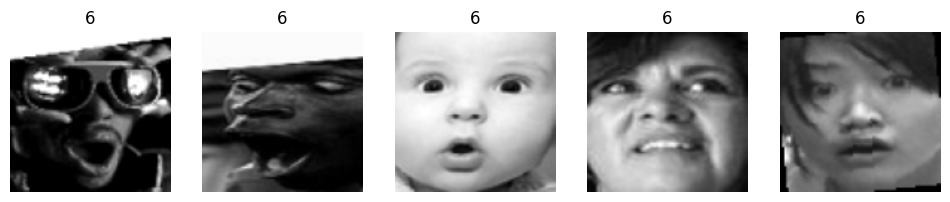

In [26]:
plt.figure(figsize=(12,4))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(data[i], cmap='gray')

    plt.title(labels[i])

    plt.axis('off')

plt.show()

In [45]:
upper_faces = []

lower_faces = []

for img in data:

    # Upper -> Eyes + Eyebrows
    upper = img[15:60, :]

    # Lower -> Mouth + Chin
    lower = img[75:120, :]

    upper_faces.append(upper)

    lower_faces.append(lower)

upper_faces = np.array(upper_faces)

lower_faces = np.array(lower_faces)

print("Upper Shape :", upper_faces.shape)

print("Lower Shape :", lower_faces.shape)

Upper Shape : (7000, 45, 128)
Lower Shape : (7000, 45, 128)


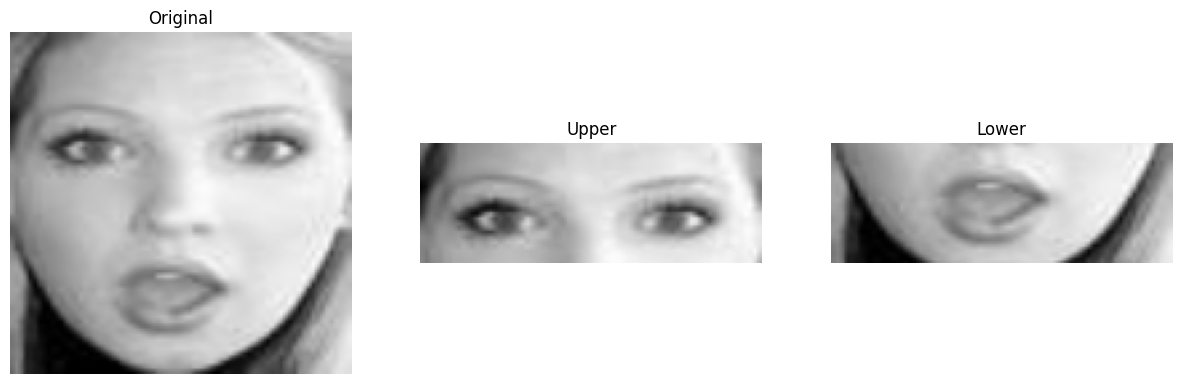

In [50]:
sample = 20
fig, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].imshow(data[sample], cmap='gray')

ax[0].set_title("Original")

ax[1].imshow(upper_faces[sample], cmap='gray')

ax[1].set_title("Upper")

ax[2].imshow(lower_faces[sample], cmap='gray')

ax[2].set_title("Lower")

for a in ax:

    a.axis('off')

plt.show()

In [51]:
def extract_hog_features(images):

    features = []

    for img in images:

        hog_features = hog(

            img,

            orientations=9,

            pixels_per_cell=(8,8),

            cells_per_block=(2,2),

            block_norm='L2-Hys'
        )

        features.append(hog_features)

    return np.array(features)

In [52]:
# Original Face
X_original = extract_hog_features(data)

# Upper Face
X_upper = extract_hog_features(upper_faces)

# Lower Face
X_lower = extract_hog_features(lower_faces)

print("Original Shape:", X_original.shape)

print("Upper Shape   :", X_upper.shape)

print("Lower Shape   :", X_lower.shape)

Original Shape: (7000, 8100)
Upper Shape   : (7000, 2160)
Lower Shape   : (7000, 2160)


In [53]:
XO_train, XO_test, y_train, y_test = train_test_split(

    X_original,

    labels,

    test_size=0.2,

    random_state=42,

    stratify=labels
)

XU_train, XU_test, _, _ = train_test_split(

    X_upper,

    labels,

    test_size=0.2,

    random_state=42,

    stratify=labels
)

XL_train, XL_test, _, _ = train_test_split(

    X_lower,

    labels,

    test_size=0.2,

    random_state=42,

    stratify=labels
)

In [54]:
# Original
scaler_O = StandardScaler()

XO_train = scaler_O.fit_transform(XO_train)

XO_test = scaler_O.transform(XO_test)

# Upper
scaler_U = StandardScaler()

XU_train = scaler_U.fit_transform(XU_train)

XU_test = scaler_U.transform(XU_test)

# Lower
scaler_L = StandardScaler()

XL_train = scaler_L.fit_transform(XL_train)

XL_test = scaler_L.transform(XL_test)

In [55]:
svm_original = SVC(kernel='linear')

svm_upper = SVC(kernel='linear')

svm_lower = SVC(kernel='linear')

svm_original.fit(XO_train, y_train)

svm_upper.fit(XU_train, y_train)

svm_lower.fit(XL_train, y_train)

SVC(kernel='linear')

In [56]:
pred_original = svm_original.predict(XO_test)

pred_upper = svm_upper.predict(XU_test)

pred_lower = svm_lower.predict(XL_test)

In [57]:
acc_original = accuracy_score(y_test, pred_original)

acc_upper = accuracy_score(y_test, pred_upper)

acc_lower = accuracy_score(y_test, pred_lower)

print("Original Accuracy:", acc_original)

print("Upper Accuracy:", acc_upper)

print("Lower Accuracy:", acc_lower)

Original Accuracy: 0.6478571428571429
Upper Accuracy: 0.425
Lower Accuracy: 0.45714285714285713


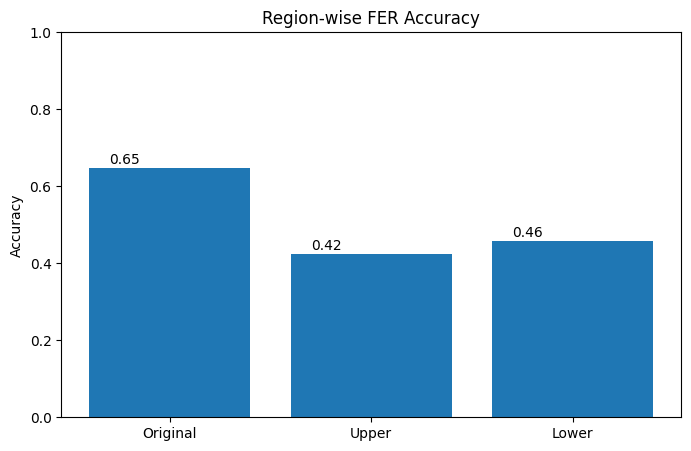

In [58]:
regions = ['Original', 'Upper', 'Lower']

accuracies = [

    acc_original,

    acc_upper,

    acc_lower
]

plt.figure(figsize=(8,5))

bars = plt.bar(regions, accuracies)

plt.ylabel("Accuracy")

plt.title("Region-wise FER Accuracy")

for bar in bars:

    yval = bar.get_height()

    plt.text(

        bar.get_x() + 0.1,

        yval + 0.01,

        round(yval,2)
    )

plt.ylim(0,1)

plt.show()

In [59]:
print("\nORIGINAL FACE\n")

print(classification_report(y_test, pred_original))

print("\nUPPER FACE\n")

print(classification_report(y_test, pred_upper))

print("\nLOWER FACE\n")

print(classification_report(y_test, pred_lower))


ORIGINAL FACE

              precision    recall  f1-score   support

           0       0.65      0.74      0.69       200
           1       0.52      0.58      0.55       200
           2       0.72      0.76      0.74       200
           3       0.80      0.74      0.77       200
           4       0.54      0.53      0.54       200
           5       0.57      0.50      0.53       200
           6       0.75      0.68      0.71       200

    accuracy                           0.65      1400
   macro avg       0.65      0.65      0.65      1400
weighted avg       0.65      0.65      0.65      1400


UPPER FACE

              precision    recall  f1-score   support

           0       0.43      0.54      0.48       200
           1       0.34      0.36      0.35       200
           2       0.51      0.58      0.55       200
           3       0.42      0.39      0.40       200
           4       0.38      0.36      0.37       200
           5       0.37      0.32      0.34      

In [60]:
report_upper = classification_report(

    y_test,

    pred_upper,

    output_dict=True
)

report_lower = classification_report(

    y_test,

    pred_lower,

    output_dict=True
)

emotion_analysis = []

for i, emotion in enumerate(emotion_names):

    upper_recall = report_upper[str(i)]['recall']

    lower_recall = report_lower[str(i)]['recall']

    if upper_recall > lower_recall:

        best_region = "Upper"

    else:

        best_region = "Lower"

    emotion_analysis.append([

        emotion,

        round(upper_recall,2),

        round(lower_recall,2),

        best_region
    ])

df_emotion = pd.DataFrame(

    emotion_analysis,

    columns=[

        'Emotion',

        'Upper',

        'Lower',

        'Best Region'
    ]
)

print(df_emotion)

    Emotion  Upper  Lower Best Region
0     Angry   0.54   0.47       Upper
1   Disgust   0.36   0.40       Lower
2      Fear   0.58   0.58       Upper
3     Happy   0.39   0.60       Lower
4   Neutral   0.36   0.41       Lower
5       Sad   0.32   0.29       Upper
6  Surprise   0.43   0.44       Lower


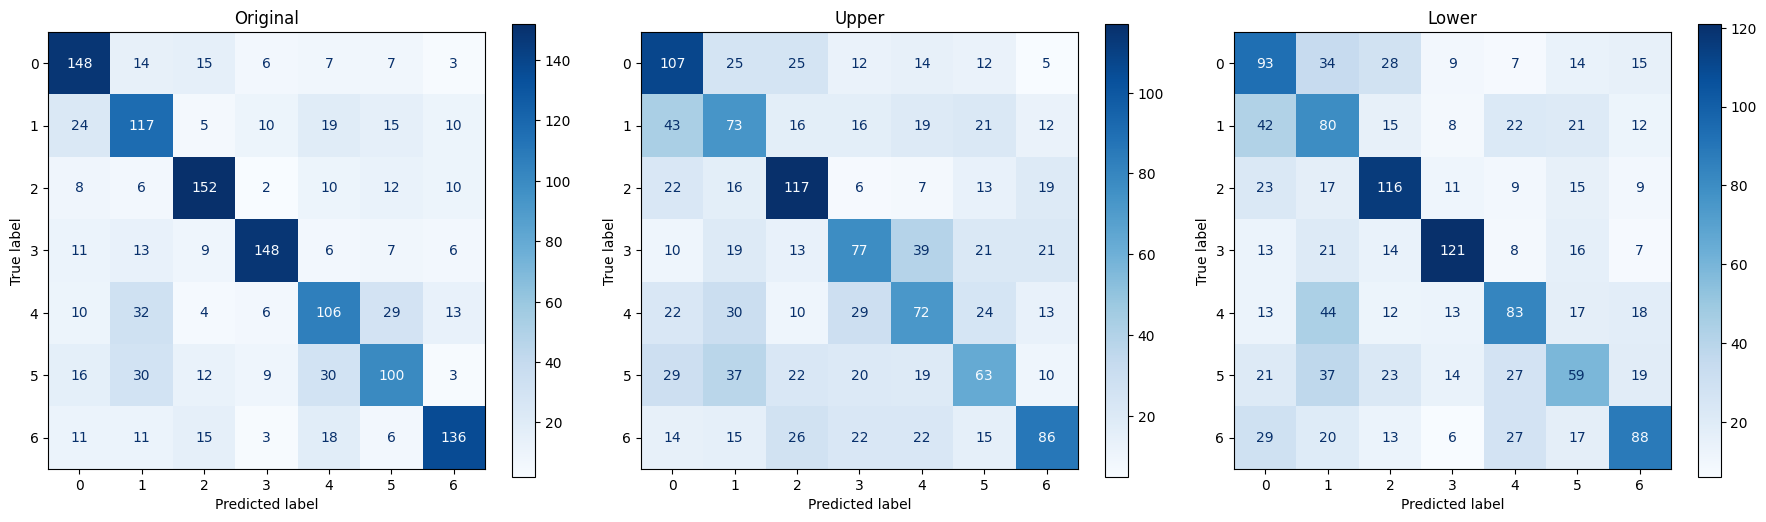

In [61]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

# Original
ConfusionMatrixDisplay.from_predictions(

    y_test,

    pred_original,

    ax=axes[0],

    cmap='Blues'
)

axes[0].set_title("Original")

# Upper
ConfusionMatrixDisplay.from_predictions(

    y_test,

    pred_upper,

    ax=axes[1],

    cmap='Blues'
)

axes[1].set_title("Upper")

# Lower
ConfusionMatrixDisplay.from_predictions(

    y_test,

    pred_lower,

    ax=axes[2],

    cmap='Blues'
)

axes[2].set_title("Lower")

plt.tight_layout()

plt.show()